In [67]:
import sys
import rbms

print(sys.executable)
print(rbms.__file__)


/Users/aidan/Documents/Research Internship/Code/rbms/.venv/bin/python
/Users/aidan/Documents/Research Internship/Code/rbms/rbms/__init__.py


In [68]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from rbms.correlations import compute_2b_correlations, compute_3b_correlations
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.partition_function.ais import compute_partition_function_ais
from rbms.plot import plot_image, plot_mult_PCA, process_corr
from rbms.dataset.utils import get_covariance_matrix
from rbms.utils import (
    compute_log_likelihood,
    get_eigenvalues_history,
    get_saved_updates,
)
from tqdm import tqdm

device = "cpu"
dtype = torch.float32

# use LaTeX fonts in the plots
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 15})
plt.rcParams["text.usetex"] = False
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
filename = "pcd_trains/BEBM_MNIST_first_test.h5"

train_dataset_name = "data/MNIST_train.h5"
test_dataset_name = "data/MNIST_test.h5"


# Load dataset


In [70]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)
num_visibles = train_dataset.get_num_visibles()
num_states = train_dataset.get_num_states()

if test_dataset is None:
    with h5py.File(filename, "r") as f:
        seed = f["hyperparameters"]["seed"][()].item()
        train_size = f["hyperparameters"]["train_size"][()].item()
    rng = np.random.default_rng(seed)
    train_dataset, test_dataset = train_dataset.split_train_test(rng, train_size)
print(train_dataset)

data = train_dataset.data.to(device).float()
cov_data = torch.tensor(
    get_covariance_matrix(data, train_dataset.weights, device=device), device=device
).float()
U_data, S_data, V_dataT = torch.linalg.svd(cov_data)

data_proj = data @ V_dataT.mT
data_proj = data_proj.cpu().numpy()

Reading dataset from data/MNIST_train.h5...
    Done
Reading dataset from data/MNIST_test.h5...
    Done

Dataset: data/MNIST_train.h5
Variable type: bernoulli
Number of samples: 60000
Number of features: 784



/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_14861/1852603193.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cov_data = torch.tensor(


# Load RBM


In [71]:
saved_updates = get_saved_updates(filename)

print(f"Saved updates:\n {saved_updates}\n")

params, perm_chains, _ = load_model(
    filename=filename, index=saved_updates[-1], device=device, dtype=dtype
)


Saved updates:
 [  1 112 223 334 445 556 667 778 889]



# Eigenvalues of the weight matrix

Monitoring the eigenvalues of the weight matrix of the RBM can tell you if the training is going as expected and not breaking.

See : [Decelle A, Fissore G, Furtlehner C. Thermodynamics of restricted Boltzmann machines and related learning dynamics. Journal of Statistical Physics. 2018 Sep;172(6):1576-608.](https://arxiv.org/pdf/1803.01960)


In [72]:
# x, y = get_eigenvalues_history(filename)
# fig, ax = plt.subplots(1, 1)
# ax.plot(x, y)
# ax.set_xlabel("Training time (gradient updates)")
# ax.set_ylabel(r"$\bm w$")
# ax.loglog()

# Permanent chains

The last configurations of the permanent chains used to train the RBM are saved in the model's archive.
Looking at them is a way to check how the training is going, however they are not necessarily equilibrium configurations of the
model.


(<Figure size 1600x400 with 16 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

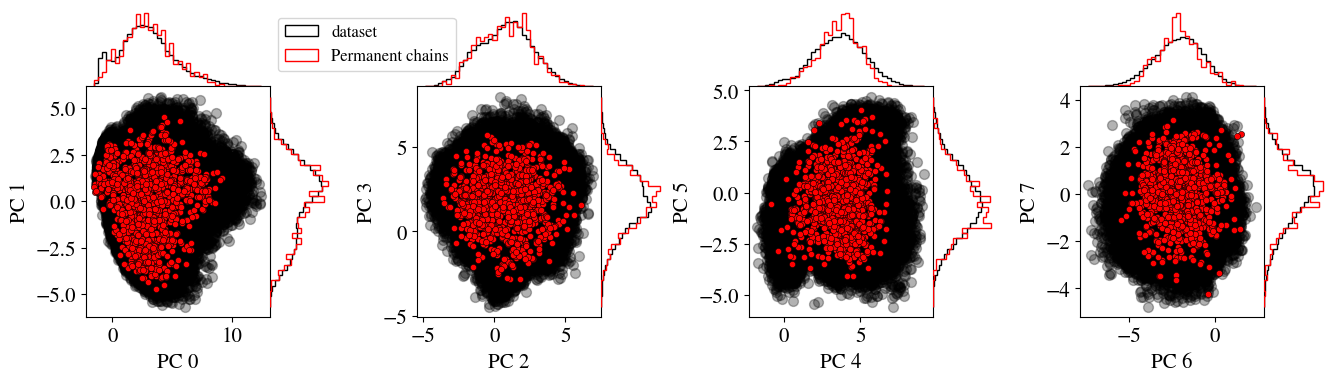

In [73]:
pc_proj = perm_chains["visible"] @ V_dataT.mT
pc_proj = pc_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :8],
    pc_proj[:, :8],
    labels=["dataset", "Permanent chains"],
)

# Sample the RBM


(<Figure size 1600x800 with 32 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

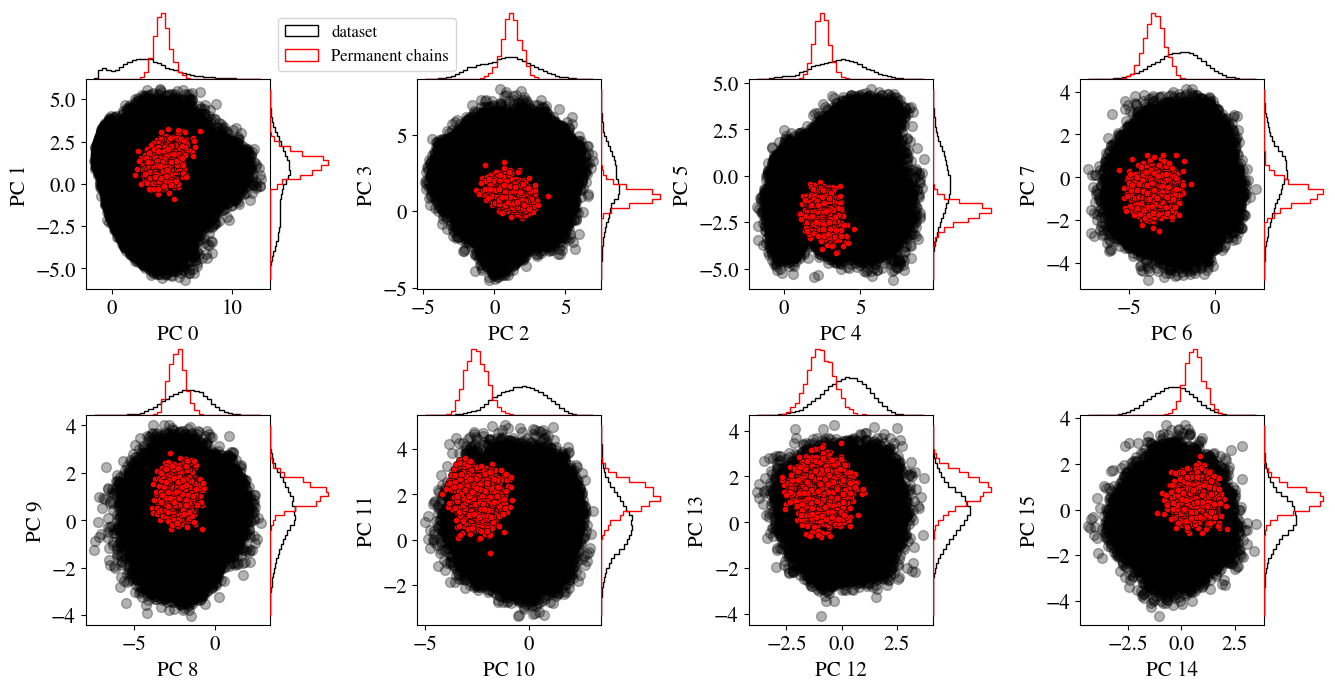

In [74]:
num_samples = 2000
n_steps = 1000


samples = params.init_chains(num_samples=num_samples)
samples = params.sample_state(chains=samples, n_steps=n_steps)

samples_proj = samples["visible"] @ V_dataT.mT
samples_proj = samples_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :16],
    samples_proj[:, :16],
    labels=["dataset", "Permanent chains"],
)

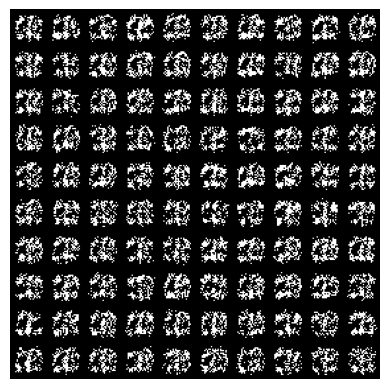

In [75]:
from rbms import plot_image
plot_image(
    samples["visible"].cpu().numpy(),
    shape=(28, 28),
    grid_size=(10, 10),
    randomize=True,
)


# Log likelihood (Annealed Importance Sampling)

The Log likelihood is given by $$\mathcal{L}_\mathrm{train} = -E(\bm v_\mathrm{train}) - \log Z$$ $$\mathcal{L}_\mathrm{test} = -E(\bm v_\mathrm{test}) - \log Z$$
So we only need to compute $\log Z$ once


In [76]:
# num_chains = 1000
# num_beta = 5000

# ll_train = np.zeros(len(saved_updates))
# ll_test = np.zeros(len(saved_updates))
# for i, upd in tqdm(enumerate(saved_updates), total=len(saved_updates), leave=False):
#     params = load_params(filename, upd, device, dtype)
#     log_z = compute_partition_function_ais(num_chains, num_beta, params)
#     ll_train[i] = compute_log_likelihood(
#         train_dataset.data, train_dataset.weights, params, log_z
#     )
#     ll_test[i] = compute_log_likelihood(
#         test_dataset.data, test_dataset.weights, params, log_z
#     )

ValueError: x and y must have same first dimension, but have shapes (9,) and (10,)

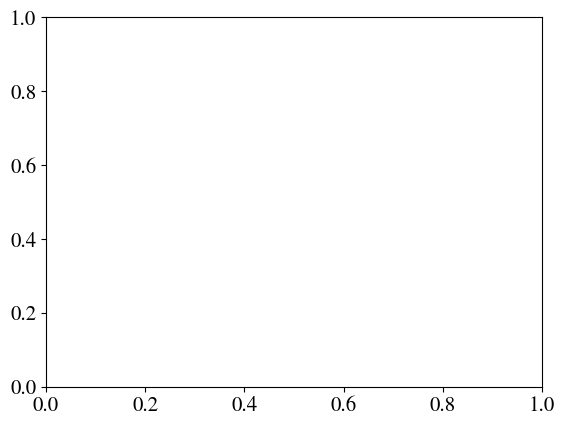

In [77]:
fig, ax = plt.subplots(1, 1)
ax.plot(saved_updates, ll_train, label="Train", color="#BF3B3B")
ax.plot(saved_updates, ll_test, label="Test", ls="--", color="#BF3B3B")
ax.set_xlabel("Training time (gradient updates)")
ax.set_ylabel("LL (nats)")
ax.legend()
ax.semilogx()

# Moment comparison

For each of the moment, we plot its estimation on the train set and on the currently considered dataset.

$m$ corresponds to the directing coefficient of a fitted line

$r$ corresponds to the pearson correlation coefficient between the two estimations


In [ ]:
corr_1b_train = train_dataset.data.mean(0).cpu().numpy()
corr_1b_test = test_dataset.data.mean(0).cpu().numpy()

corr_1b_pc = perm_chains["visible"].mean(0).cpu().numpy()
corr_1b_samples = samples["visible"].mean(0).cpu().numpy()

Text(0.5, 0.98, 'Frequencies')

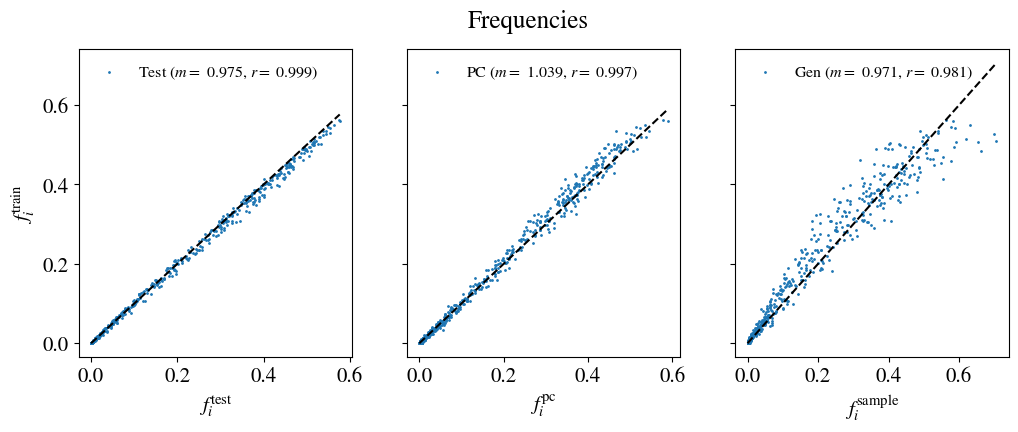

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m1_test, r1_test, x, y, x_line = process_corr(corr_1b_test, corr_1b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m1_test:.3f}, $r=$ {r1_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$f_{i}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$f_{i}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_pc, r1_pc, x, y, x_line = process_corr(corr_1b_pc, corr_1b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m1_pc:.3f}, $r=$ {r1_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$f_{i}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_samples, r1_samples, x, y, x_line = process_corr(corr_1b_samples, corr_1b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m1_samples:.3f}, $r=$ {r1_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$f_{i}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Frequencies")

In [ ]:
corr_2b_train = (
    compute_2b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_test = (
    compute_2b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_pc = (
    compute_2b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)
corr_2b_samples = (
    compute_2b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)

AssertionError: Torch not compiled with CUDA enabled

Text(0.5, 0.98, 'Covariances')

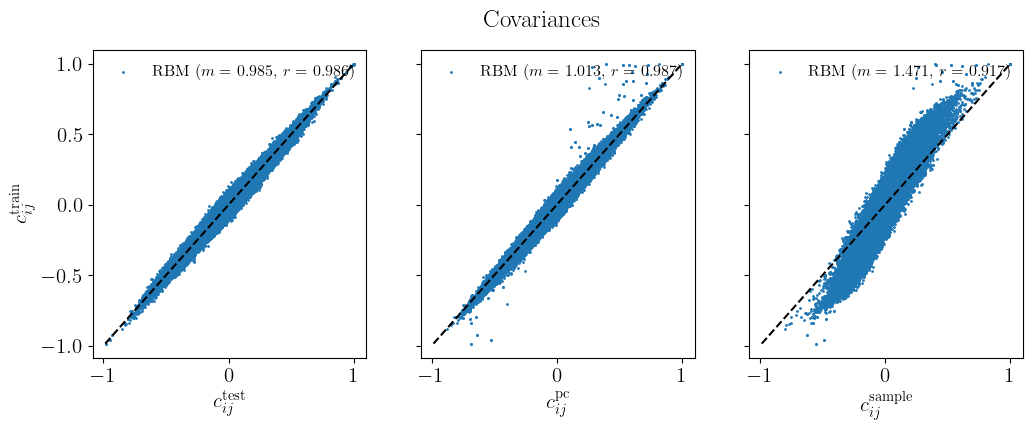

In [ ]:
threshold = 0.0

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

m2_test, r2_test, x, y, x_line = process_corr(corr_2b_test, corr_2b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m2_test:.3f}, $r=$ {r2_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ij}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ij}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_pc, r2_pc, x, y, x_line = process_corr(corr_2b_pc, corr_2b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m2_pc:.3f}, $r=$ {r2_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ij}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_samples, r2_samples, x, y, x_line = process_corr(corr_2b_samples, corr_2b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m2_samples:.3f}, $r=$ {r2_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ij}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Covariances")

In [ ]:
corr_3b_train = (
    compute_3b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_test = (
    compute_3b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_pc = (
    compute_3b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_samples = (
    compute_3b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)

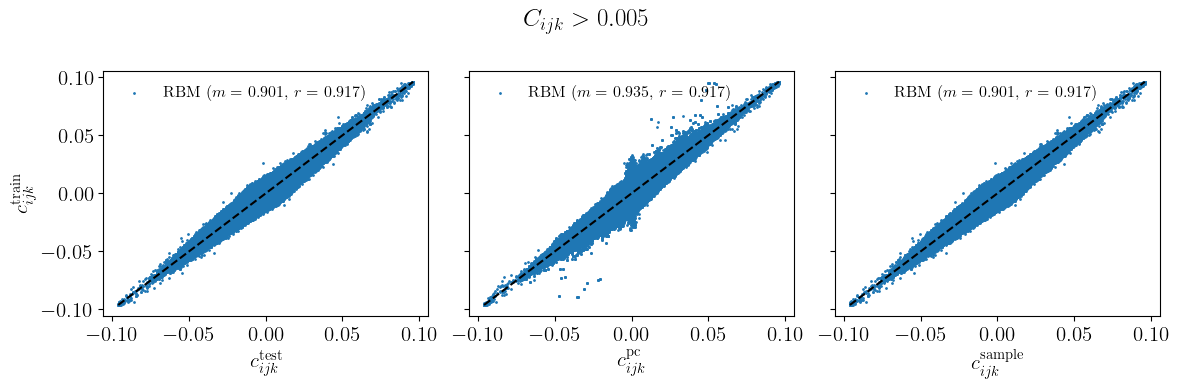

In [ ]:
# Terribly slow because of the number of points to plot

threshold = 0.005
mask = (np.abs(corr_3b_train) > threshold) | (np.abs(corr_3b_test) > threshold)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m3_test, r3_test, x, y, x_line = process_corr(corr_3b_test, corr_3b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m3_test:.3f}, $r=$ {r3_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ijk}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ijk}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_pc, r3_pc, x, y, x_line = process_corr(corr_3b_pc, corr_3b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m3_pc:.3f}, $r=$ {r3_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ijk}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_samples, r3_samples, x, y, x_line = process_corr(corr_3b_samples, corr_3b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m3_samples:.3f}, $r=$ {r3_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ijk}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle(r"$C_{ijk} > 0.005$")
fig.tight_layout()

# Plot images

If your dataset is an image dataset, you can plot images and generated data here


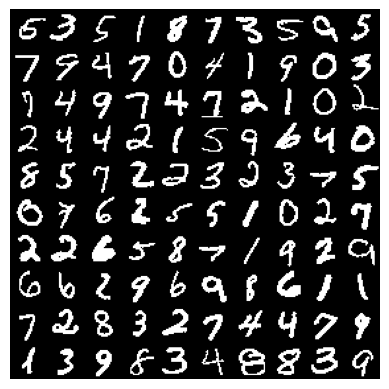

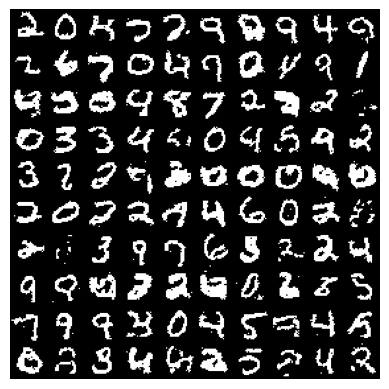

In [ ]:
img_shape = (28, 28)
grid_size = (10, 10)
randomize = True


plot_image(
    train_dataset.data.cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)

plot_image(
    samples["visible"].cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)